# TopGrad-CF Implementation Comparison — Coffee

This notebook compares our PyTorch port (`cfts/cf_topgrad/topgrad_cf.py`) against the **authors' own reference implementation** on the **Coffee** dataset (UCR, univariate, binary: Arabica vs. Robusta) — the dataset `Main.py` in the reference repo itself is actually configured to run (the other nine are present but commented out).

| Variant | Source | Notes |
|---|---|---|
| `topgrad` | `topgrad_cf.py` | Our port — NUN prototype, top-k gradient masking, growing segment, **and** a classifier loss term in the optimised objective (see "Deviations" below) |
| `topgrad_original` | **Reference implementation**, run with `Main.py`'s own literal hyperparameters/defaults | `Methods/TopGrad-CF.py`'s `TFCounterFactual`, TensorFlow-1-compat graph mode |
| `topgrad_original_fixed` | Same reference code, one constructor argument corrected | See "A bug in `Main.py`" below |

**References**
- Paper: Hosseinzadeh, P. et al. (2026). *"TopGrad-CF: Gradient-Guided Counterfactual Explanations for Time Series Classification."* ICPR 2026. https://link.springer.com/chapter/10.1007/978-3-032-31933-3_35 (paywalled — not consulted directly; the comparison below is against the authors' own code)
- Repository: https://github.com/pouyahosseinzadeh/TopGrad-CF

## Deviations documented in `topgrad_cf.py`, and what running the actual repo shows

Our port's module docstring already flags that the reference's Keras/autograd optimisation path never adds the classifier loss (`loss_pred`) into the objective it backpropagates — only distance-to-original, distance-to-prototype, sparsity and smoothness. That was inferred by reading `Methods/TopGrad-CF.py`. This notebook actually **runs** that code (cloned as-is, patched only for environment compatibility — see below) against a real classifier, and the "Key findings" section near the end shows what that omission does to the target-class probability in practice, plus two more issues found only by running both implementations end-to-end on this dataset: an independent `Main.py` call-site bug, and a length-scaling bug of our own that the first draft of `topgrad_cf.py` had (fixed — see the "mean, not sum" note in its "Deviations" comment).

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_topgrad.topgrad_cf import topgrad_cf
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load Coffee dataset, and train (or load a cached) PyTorch SimpleCNN model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="Coffee", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="Coffee", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)
model_path = REPO_ROOT / "models" / f"simple_cnn_coffee_{output_classes}.pth"


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


def predict_scores(model, sample, device):
    """Return raw logits as (n_classes,) numpy array."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        ts = ts.reshape(1, ts.shape[0], ts.shape[1]) if ts.shape[0] <= ts.shape[1] else ts.T.unsqueeze(0)
    elif ts.ndim == 3:
        if ts.shape[0] != 1:
            ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


if model_path.exists():
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    print(f"Loaded model from {model_path}")
else:
    print(f"No pretrained model at {model_path} — training a SimpleCNN on Coffee (n_train={len(dataset_train)}).")

    X_train_all = torch.tensor(
        np.stack([np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(len(dataset_train))]),
        device=device,
    )
    y_train_all = torch.tensor(
        np.array([to_class_index(dataset_train[i][1]) for i in range(len(dataset_train))]),
        dtype=torch.long, device=device,
    )
    X_test_all = torch.tensor(
        np.stack([np.asarray(dataset_test[i][0], dtype=np.float32) for i in range(len(dataset_test))]),
        device=device,
    )
    y_test_all = torch.tensor(
        np.array([to_class_index(dataset_test[i][1]) for i in range(len(dataset_test))]),
        dtype=torch.long, device=device,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_acc, best_state = -1.0, None
    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_all), y_train_all)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_acc = (model(X_test_all).argmax(dim=-1) == y_test_all).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if epoch % 25 == 0:
            print(f"  epoch {epoch:3d} | train_loss={loss.item():.4f} | val_acc={val_acc:.4f}")

    model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    print(f"Trained model saved to {model_path} (best val acc={best_val_acc:.4f})")

model.eval()

y_true = [to_class_index(dataset_test[i][1]) for i in range(len(dataset_test))]
y_pred = [int(np.argmax(predict_scores(model, dataset_test[i][0], device))) for i in range(len(dataset_test))]
test_acc = float(np.mean(np.array(y_true) == np.array(y_pred)))
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"PyTorch SimpleCNN test accuracy: {test_acc:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_coffee_2.pth
Train size: 28 | Test size: 28
Input length: 286 | Classes: 2
PyTorch SimpleCNN test accuracy: 1.0000


In [3]:
# Background dataset for topgrad_cf's nearest-unlike-neighbour prototype search
background_dataset = [
    (np.asarray(dataset_train[i][0], dtype=np.float32), to_class_index(dataset_train[i][1]))
    for i in range(len(dataset_train))
]
reference_data = np.stack([x for x, _ in background_dataset], axis=0)  # for feature_range_validity

print(f"Background data: {reference_data.shape}")
print(f"Label distribution (train): {np.unique([y for _, y in background_dataset], return_counts=True)}")

Background data: (28, 1, 286)
Label distribution (train): (array([0, 1]), array([14, 14]))


## Original TopGrad-CF baseline (pouyahosseinzadeh/TopGrad-CF)

To use the authors' own code as a baseline, we clone it into a **gitignored** directory (`cfts/cf_topgrad/external/`, matched by the `**/external/` rule in `.gitignore`):

```bash
mkdir -p cfts/cf_topgrad/external
git clone https://github.com/pouyahosseinzadeh/TopGrad-CF.git cfts/cf_topgrad/external/topgrad_github
cd cfts/cf_topgrad/external/topgrad_github
cp "Methods/TopGrad-CF.py" tfcounterfactualmodified.py   # the repo's own README asks for this rename
touch utils/__init__.py                                   # see note below — no algorithmic change
```

Extra (standard, PyPI) dependencies installed into the project venv: `dill`, `tf_keras`. TensorFlow itself (2.20) was already present.

**Patches / workarounds applied — none of them touch the counterfactual algorithm itself:**
- `utils/__init__.py` (empty file, added): the cloned repo's `utils/` package has no `__init__.py`, which makes it a PEP 420 namespace package. In this project's venv another installed package also contributes a directory literally named `utils` at the top of `sys.path`; since namespace-package resolution stops at the first *regular* package it finds, that unrelated package would otherwise shadow the repo's own `utils.defaults` / `utils.interfaces`. Adding an empty `__init__.py` makes the cloned copy a regular package again so it resolves first, deterministically, regardless of what else is installed.
- `TF_USE_LEGACY_KERAS=1` (env var, set before importing TensorFlow) + the `tf_keras` package: the repo's `TFCounterFactual` uses TensorFlow-1 graph-mode APIs (`tf.compat.v1.get_variable`, `tf.compat.v1.Session`, `tf.compat.v1.keras.backend.get_session()`) against a Keras model. TensorFlow 2.20 defaults `tf.keras` to Keras 3, whose backend has no `get_session()`/legacy-optimizer support at all, so without this the constructor fails immediately. `TF_USE_LEGACY_KERAS=1` makes `tf.keras` resolve to the old Keras-2 API (via `tf_keras`), which does support it — this is TensorFlow's own documented migration path for exactly this situation, not a repo-specific patch.

If `cfts/cf_topgrad/external/topgrad_github` isn't present, or `tensorflow`/`tf_keras` fail to import, the cells below skip the `topgrad_original*` baselines gracefully and the rest of the notebook still runs with just `topgrad`.

**Hyperparameters for `topgrad_original*` mirror `Main.py`'s own call exactly**: `target_proba=0.99, tol=0.01, max_iter=500, lam_init=0.1, max_lam_steps=1, learning_rate_init=0.1, feature_range=(xtrain.min(), xtrain.max())`. The prototype is the authors' own **DTW Barycenter Average** of each class's training examples (`tslearn.barycenters.dtw_barycenter_averaging`), not a nearest-neighbour — a genuine algorithmic difference from `topgrad_cf`'s NUN prototype that we keep as-is (it's what the paper's code does) rather than "fixing" to match ours.

In [4]:
import os
import shutil
import subprocess

EXTERNAL_DIR = REPO_ROOT / "cfts" / "cf_topgrad" / "external" / "topgrad_github"
HAVE_ORIGINAL_TOPGRAD = False

if not EXTERNAL_DIR.exists():
    EXTERNAL_DIR.parent.mkdir(parents=True, exist_ok=True)
    try:
        subprocess.run(
            ["git", "clone", "-q", "https://github.com/pouyahosseinzadeh/TopGrad-CF.git", str(EXTERNAL_DIR)],
            check=True, timeout=120,
        )
    except Exception as exc:
        print(f"Could not clone the reference repo ({exc}) — skipping topgrad_original* baselines.")

if EXTERNAL_DIR.exists():
    try:
        shutil.copy(EXTERNAL_DIR / "Methods" / "TopGrad-CF.py", EXTERNAL_DIR / "tfcounterfactualmodified.py")
        (EXTERNAL_DIR / "utils" / "__init__.py").touch(exist_ok=True)

        os.environ["TF_USE_LEGACY_KERAS"] = "1"
        sys.path.insert(0, str(EXTERNAL_DIR))

        import tensorflow as tf
        import tensorflow.compat.v1 as tf1
        tf1.disable_v2_behavior()
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
        from tensorflow.keras.optimizers.legacy import Adam as TFAdam
        from tslearn.barycenters import dtw_barycenter_averaging
        import tfcounterfactualmodified as tg

        tf.random.set_seed(42)
        HAVE_ORIGINAL_TOPGRAD = True
        print(f"Loaded original TopGrad-CF implementation from {EXTERNAL_DIR}")
    except Exception as exc:
        HAVE_ORIGINAL_TOPGRAD = False
        print(f"Found {EXTERNAL_DIR} but failed to import the reference implementation ({exc}).")
        print("Install: dill, tf_keras (pip install dill tf_keras) — see the markdown cell above.")
else:
    print(f"{EXTERNAL_DIR} not found — skipping the topgrad_original* baselines.")

Instructions for updating:
non-resource variables are not supported in the long term


Loaded original TopGrad-CF implementation from /workspaces/counterfactual-explanations-for-time-series/cfts/cf_topgrad/external/topgrad_github


In [5]:
# Train the reference's own Keras classifier (Main.py::build_nn_classifier) and compute
# per-class DTW Barycenter Average prototypes (Main.py::process_dataset_timex), exactly as
# the reference Main.py does for its own experiments.

if HAVE_ORIGINAL_TOPGRAD:
    Xtr_flat = np.stack([np.asarray(dataset_train[i][0], dtype=np.float32).reshape(-1) for i in range(len(dataset_train))])
    ytr_int = np.array([to_class_index(dataset_train[i][1]) for i in range(len(dataset_train))])
    Xte_flat = np.stack([np.asarray(dataset_test[i][0], dtype=np.float32).reshape(-1) for i in range(len(dataset_test))])
    yte_int = np.array([to_class_index(dataset_test[i][1]) for i in range(len(dataset_test))])

    dba_dic = {}
    for c in range(output_classes):
        tmp = Xtr_flat[ytr_int == c]
        dba_dic[c] = dtw_barycenter_averaging(tmp, max_iter=10).reshape(1, tmp.shape[1])[0]
    print(f"DBA prototypes computed for {len(dba_dic)} classes, length {input_length}.")

    Xtr_r = Xtr_flat.reshape(Xtr_flat.shape[0], input_length, 1)
    Xte_r = Xte_flat.reshape(Xte_flat.shape[0], input_length, 1)
    ytr_oh = np.eye(output_classes, dtype=np.float32)[ytr_int]

    tf_model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(input_length, 1)),
        MaxPooling1D(pool_size=2), Dropout(0.3),
        Conv1D(filters=128, kernel_size=3, activation="relu"),
        MaxPooling1D(pool_size=2), Dropout(0.3),
        Flatten(), Dense(128, activation="relu"),
        Dense(output_classes, activation="softmax"),
    ])
    tf_model.compile(optimizer=TFAdam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    tf_model.fit(Xtr_r, ytr_oh, epochs=50, batch_size=32, verbose=0, shuffle=False)

    tf_pred = tf_model.predict(Xte_r, verbose=0)
    tf_test_acc = float((np.argmax(tf_pred, axis=1) == yte_int).mean())
    print(f"Reference Keras classifier test accuracy: {tf_test_acc:.4f}")

    def predict_proba_original(Xb: np.ndarray) -> np.ndarray:
        """(N, L, 1) or (N, C, L) float -> (N, n_classes) softmax probabilities."""
        Xb = np.asarray(Xb, dtype=np.float32)
        if Xb.ndim == 3 and Xb.shape[1] == 1 and Xb.shape[2] != 1:
            Xb = np.transpose(Xb, (0, 2, 1))  # (N, C, L) -> (N, L, C)
        return tf_model.predict(Xb, verbose=0)

    def model_wrapper_original(ts) -> np.ndarray:
        """(L,) or (C, L) -> (n_classes,) scores, matching model_wrapper's contract for our metrics."""
        arr = to_channel_first(ts)  # (C, L)
        return predict_proba_original(arr.reshape(1, arr.shape[0], arr.shape[1]))[0]

DBA prototypes computed for 2 classes, length 286.


I0000 00:00:1787063423.763684   52622 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
W0000 00:00:1787063423.778769   52622 c_api.cc:305] Operation '{name:'training/Adam/dense/kernel/v/Assign' id:461 op device:{requested: '', assigned: ''} def:{{{node training/Adam/dense/kernel/v/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](training/Adam/dense/kernel/v, training/Adam/dense/kernel/v/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


Reference Keras classifier test accuracy: 0.9643


W0000 00:00:1787063424.167533   52622 c_api.cc:305] Operation '{name:'dense_1/Softmax' id:140 op device:{requested: '', assigned: ''} def:{{{node dense_1/Softmax}} = Softmax[T=DT_FLOAT, _has_manual_control_dependencies=true](dense_1/BiasAdd)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


In [6]:
# Wrapper around the reference TFCounterFactual, run with Main.py's own hyperparameters.
# `fix_target_classid`: Main.py's own call site never passes `target_classid` (see "Key
# findings" below) — pass True to correct that one constructor argument, everything else
# stays identical to Main.py.

def run_topgrad_original(sample_raw: np.ndarray, target_class: int, fix_target_classid: bool):
    x_cl = to_channel_first(sample_raw).astype(np.float32)  # (1, L)
    instance = x_cl.reshape(1, input_length, 1)
    prototype = dba_dic[target_class].reshape(1, input_length, 1)

    kwargs = dict(
        shape=(1, input_length, 1),
        target_proba=0.99,
        tol=0.01,
        target_class=int(target_class),
        max_iter=500,
        lam_init=1e-1,
        max_lam_steps=1,
        learning_rate_init=0.1,
        feature_range=(float(Xtr_flat.min()), float(Xtr_flat.max())),
        num_classes=output_classes,
    )
    if fix_target_classid:
        kwargs["target_classid"] = int(target_class)

    explainer = tg.TFCounterFactual(tf_model, **kwargs)
    explanation = explainer.explain(instance, prototype)
    cf = np.asarray(explanation.cf, dtype=np.float32).reshape(1, -1)  # (1, L)
    scores = predict_proba_original(cf.reshape(1, input_length, 1))[0]
    return cf, scores

In [7]:
def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """(N, L) or (C, L) -> scores array, for metrics helpers (our PyTorch model)."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def infer_target_class(true_label: int, n_classes: int) -> int:
    """Any class other than the true label — matches Main.py's `possible_classes[0]`,
    which for binary classification is simply "the other class"."""
    return next(c for c in range(n_classes) if c != true_label)


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def compute_metrics(sample_cf, cf_cf, target_class, model_fn):
    """Quality metrics for (sample, counterfactual) both as (C, L) arrays, judged against
    `model_fn` — each variant's *own* target classifier, not necessarily ours."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_fn,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, reference_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_fn, target_class=target_class)),
    }

In [8]:
N_SAMPLES = 12  # Coffee's test split only has 28 instances total

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 12 correctly classified test samples.


In [9]:
METHODS = ["topgrad"]
METHOD_COLORS = ["#2a9d8f"]
MODEL_FN = {"topgrad": model_wrapper}

if HAVE_ORIGINAL_TOPGRAD:
    METHODS += ["topgrad_original", "topgrad_original_fixed"]
    METHOD_COLORS += ["#e76f51", "#264653"]
    MODEL_FN["topgrad_original"] = model_wrapper_original
    MODEL_FN["topgrad_original_fixed"] = model_wrapper_original

# kept modest vs. topgrad_cf's own defaults so the notebook runs in a couple of minutes;
# see cfts/cf_topgrad/topgrad_cf.py's own "Deviations" note for why its defaults are
# already lower than the reference's max_iter=500 / max_lam_steps~10 / ~65 outer steps.
TOPGRAD_KWARGS = dict(
    max_iter=150, n_lambda_orders=4, max_lam_steps=3,
    early_stop=20, max_outer_steps=8, top_k_frac=0.05,
    seed=42, verbose=False,
)


def run_topgrad(sample_raw, target_class, variant: str):
    if variant == "topgrad_original":
        return run_topgrad_original(sample_raw, target_class, fix_target_classid=False)
    if variant == "topgrad_original_fixed":
        return run_topgrad_original(sample_raw, target_class, fix_target_classid=True)
    if variant == "topgrad":
        return topgrad_cf(sample_raw, model, target_class=target_class, dataset=background_dataset, **TOPGRAD_KWARGS)
    raise ValueError(f"Unknown variant: {variant}")

In [10]:
records = []
all_cfs = {}  # {sample_idx: {method: cf_array}}

for i, idx in enumerate(selected_indices):
    sample_raw, label = dataset_test[idx]
    sample_raw = np.asarray(sample_raw, dtype=np.float32)
    true_label = to_class_index(label)
    target_class = infer_target_class(true_label, output_classes)
    pred_orig = int(np.argmax(model_wrapper(sample_raw)))

    all_cfs[idx] = {"sample": sample_raw, "true_label": true_label, "target_class": target_class}

    base = {
        "sample_idx": idx,
        "true_label": true_label,
        "pred_orig": pred_orig,
        "target_class": target_class,
    }

    for variant in METHODS:
        t0 = time.time()
        try:
            cf, cf_scores = run_topgrad(sample_raw, target_class, variant)
            cf = np.asarray(cf, dtype=np.float32)
            cf_scores = np.asarray(cf_scores).reshape(-1)
            pred_cf = int(np.argmax(cf_scores))
            success = pred_cf == target_class
            sample_cl = to_channel_first(sample_raw)
            cf_cl = to_channel_first(cf)
            metrics = compute_metrics(sample_cl, cf_cl, target_class, MODEL_FN[variant])
            records.append({
                **base, "method": variant,
                "pred_cf": pred_cf, "success": bool(success),
                "target_proba_cf": float(cf_scores[target_class]),
                "runtime_s": time.time() - t0,
                **metrics, "error": None,
            })
            all_cfs[idx][variant] = cf
        except Exception as exc:
            records.append({
                **base, "method": variant,
                "pred_cf": None, "success": False,
                "runtime_s": time.time() - t0,
                "error": f"{type(exc).__name__}: {exc}",
            })

    print(f"[{i + 1}/{len(selected_indices)}] Completed sample {idx}")

results_df = pd.DataFrame(records)
print(f"Evaluation complete. Total records: {len(results_df)}")
results_df.head(9)

Model is Keras...
[[0.8636818  0.13631815]]
One hot of targhet is [[1. 0.]]
[1.e-01 1.e-02 1.e-03 1.e-04 1.e-05 1.e-06 1.e-07 1.e-08 1.e-09 1.e-10]
Number of steps 50


The lower bound lambda is [0.1]
ub_ix is 9
Found the optimal lambda at [0.05]
Prob array is
0
CF SEG IS 14
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8636818  0.13631815]]
0.8636818
Target class proba is
0.8636818
The rate is 0.060000000000000005
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8636818
CF SEG IS 17
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.07
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 20
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.08
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 23
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target cla

The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.09999999999999999
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 29
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.10999999999999999
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 31
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.11999999999999998
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 34
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.12999999999999998
++++++++++++++++++++++++

The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.13999999999999999
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 40
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.15
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 43
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.16
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 46
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.17
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF

The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.18000000000000002
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 51
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.19000000000000003
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 54
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.20000000000000004
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.8616557
CF SEG IS 57
The Original predicted class is [[0.8636818  0.13631815]]
The CF predicted class is [[0.8616557  0.13834427]]
0.8616557
Target class proba is
0.8616557
The rate is 0.21000000000000005
++++++++++++++++++++++++

...

The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.5900000000000003
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 169
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6000000000000003
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 172
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6100000000000003
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 174
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6200000000000003
+++++++++++

The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6300000000000003
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 180
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6400000000000003
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 183
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6500000000000004
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 186
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6600000000000004
+++++++++++

The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6700000000000004
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 192
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6800000000000004
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 194
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.6900000000000004
++++++++++++++++++++++++++++++++++++++++++
Prob array is
0.009766054
CF SEG IS 197
The Original predicted class is [[0.9906646  0.00933542]]
The CF predicted class is [[0.9902339  0.00976605]]
0.9902339
Target class proba is
0.009766054
The rate is 0.7000000000000004
+++++++++++

[12/12] Completed sample 11
Evaluation complete. Total records: 36


,sample_idx,true_label,pred_orig,target_class,method,pred_cf,success,target_proba_cf,runtime_s,l2_norm,dtw_proximity,normalized_distance,sparsity,range_validity,autocorr,keane_validity,keane_proximity,keane_compactness,validity,error
0,0,0,0,1,topgrad,1,True,0.558949,3.471652,0.683030,0.495378,0.010595,0.940559,0.909091,0.999714,1.0,0.683030,0.940559,1.0,None
1,0,0,0,1,topgrad_original,0,False,0.130410,3.816345,0.099044,0.099044,0.001536,0.972028,0.909091,1.000000,0.0,0.099044,0.979021,0.0,None
2,0,0,0,1,topgrad_original_fixed,0,False,0.130410,3.769045,0.099044,0.099044,0.001536,0.972028,0.909091,1.000000,0.0,0.099044,0.979021,0.0,None
3,1,0,0,1,topgrad,1,True,0.520280,2.321011,2.205975,2.198132,0.034797,0.993007,0.895105,0.998681,1.0,2.205975,0.993007,1.0,None
4,1,0,0,1,topgrad_original,0,False,0.032314,0.627247,0.000000,0.000000,0.000000,1.000000,0.898601,1.000000,0.0,0.000000,1.000000,0.0,None
5,1,0,0,1,topgrad_original_fixed,0,False,0.031711,4.072482,0.023401,0.023401,0.000369,0.972028,0.898601,1.000000,0.0,0.023401,0.993007,0.0,None
6,2,0,0,1,topgrad,1,True,0.508291,2.839889,1.174936,0.914082,0.018027,0.989510,0.902098,0.999822,1.0,1.174936,0.989510,1.0,None
7,2,0,0,1,topgrad_original,0,False,0.161890,3.869688,0.065770,0.065770,0.001009,0.972028,0.905594,1.000000,0.0,0.065770,0.982517,0.0,None
8,2,0,0,1,topgrad_original_fixed,0,False,0.161890,3.922177,0.065770,0.065770,0.001009,0.972028,0.905594,1.000000,0.0,0.065770,0.982517,0.0,None


In [11]:
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
        target_proba_cf_mean=("target_proba_cf", "mean"),
        runtime_s_mean=("runtime_s", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)

display_cols = [
    "method", "n_successful", "success_rate", "validity_mean", "target_proba_cf_mean",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "range_validity_mean", "autocorr_mean", "runtime_s_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,validity_mean,target_proba_cf_mean,l2_norm_mean,dtw_proximity_mean,sparsity_mean,range_validity_mean,autocorr_mean,runtime_s_mean
0,topgrad,12,100.0,1.0000,0.5231,1.6688,1.5236,0.9878,0.9464,0.999,3.3907
1,topgrad_original,1,8.3,0.0833,0.1059,0.0239,0.0239,0.9720,0.9056,1.000,2.1883
2,topgrad_original_fixed,1,8.3,0.0833,0.1059,0.0239,0.0239,0.9720,0.9056,1.000,4.1989


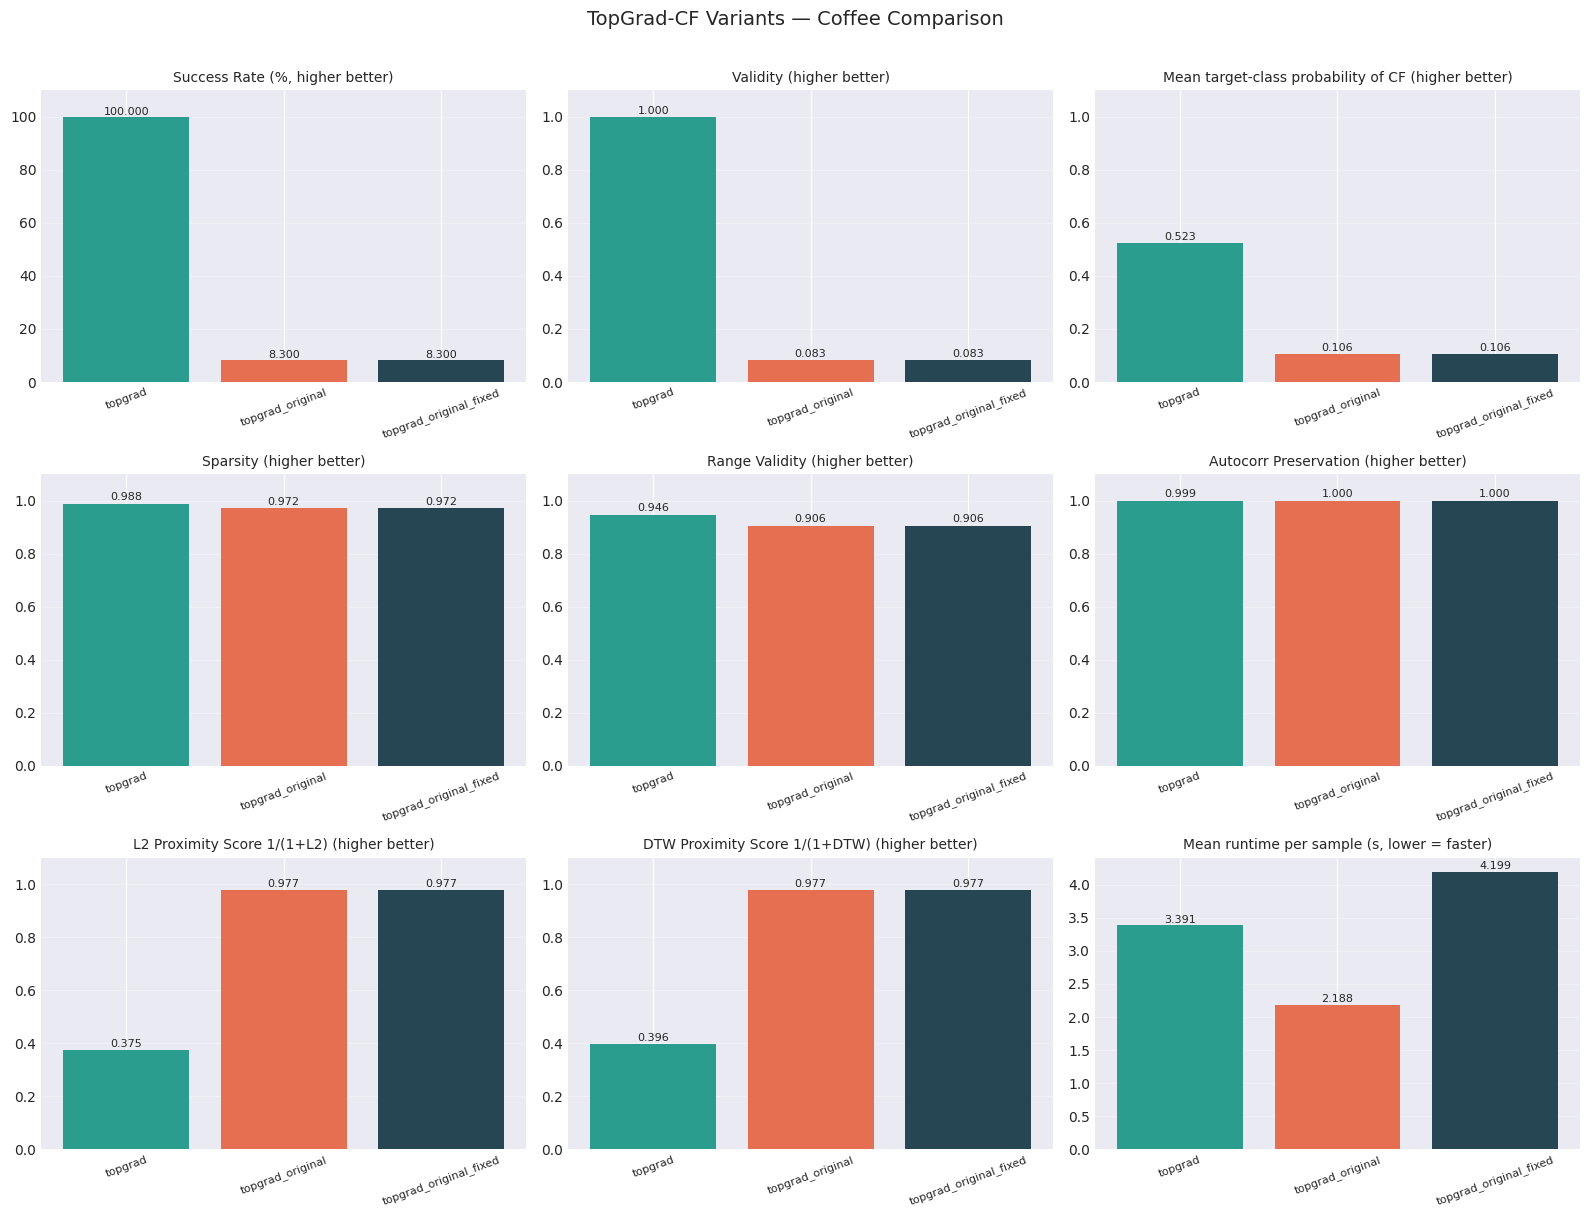

In [12]:
plot_df = summary_df.set_index("method").loc[METHODS].reset_index()
methods = plot_df["method"].tolist()
colors = METHOD_COLORS[: len(methods)]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"].fillna(np.inf))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("TopGrad-CF Variants — Coffee Comparison", fontsize=14, y=1.01)

bar(axes[0, 0], plot_df["success_rate"], "Success Rate (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["validity_mean"].fillna(0), "Validity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["target_proba_cf_mean"].fillna(0),
    "Mean target-class probability of CF (higher better)", ylim=(0, 1.1))
bar(axes[1, 0], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], plot_df["range_validity_mean"].fillna(0), "Range Validity (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["autocorr_mean"].fillna(0), "Autocorr Preservation (higher better)", ylim=(0, 1.1))
bar(axes[2, 0], l2_score, "L2 Proximity Score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[2, 1], dtw_score, "DTW Proximity Score 1/(1+DTW) (higher better)", ylim=(0, 1.1))
bar(axes[2, 2], plot_df["runtime_s_mean"].fillna(0), "Mean runtime per sample (s, lower = faster)")

plt.tight_layout()
plt.show()

In [13]:
# Pick a sample where all methods succeeded (prefer all-success, fall back to most-success)
success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)

full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(METHODS)]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])

print(f"Representative sample index: {rep_idx}")
print(f"Methods succeeded: {int(success_counts[rep_idx])} / {len(METHODS)}")

Representative sample index: 6
Methods succeeded: 3 / 3


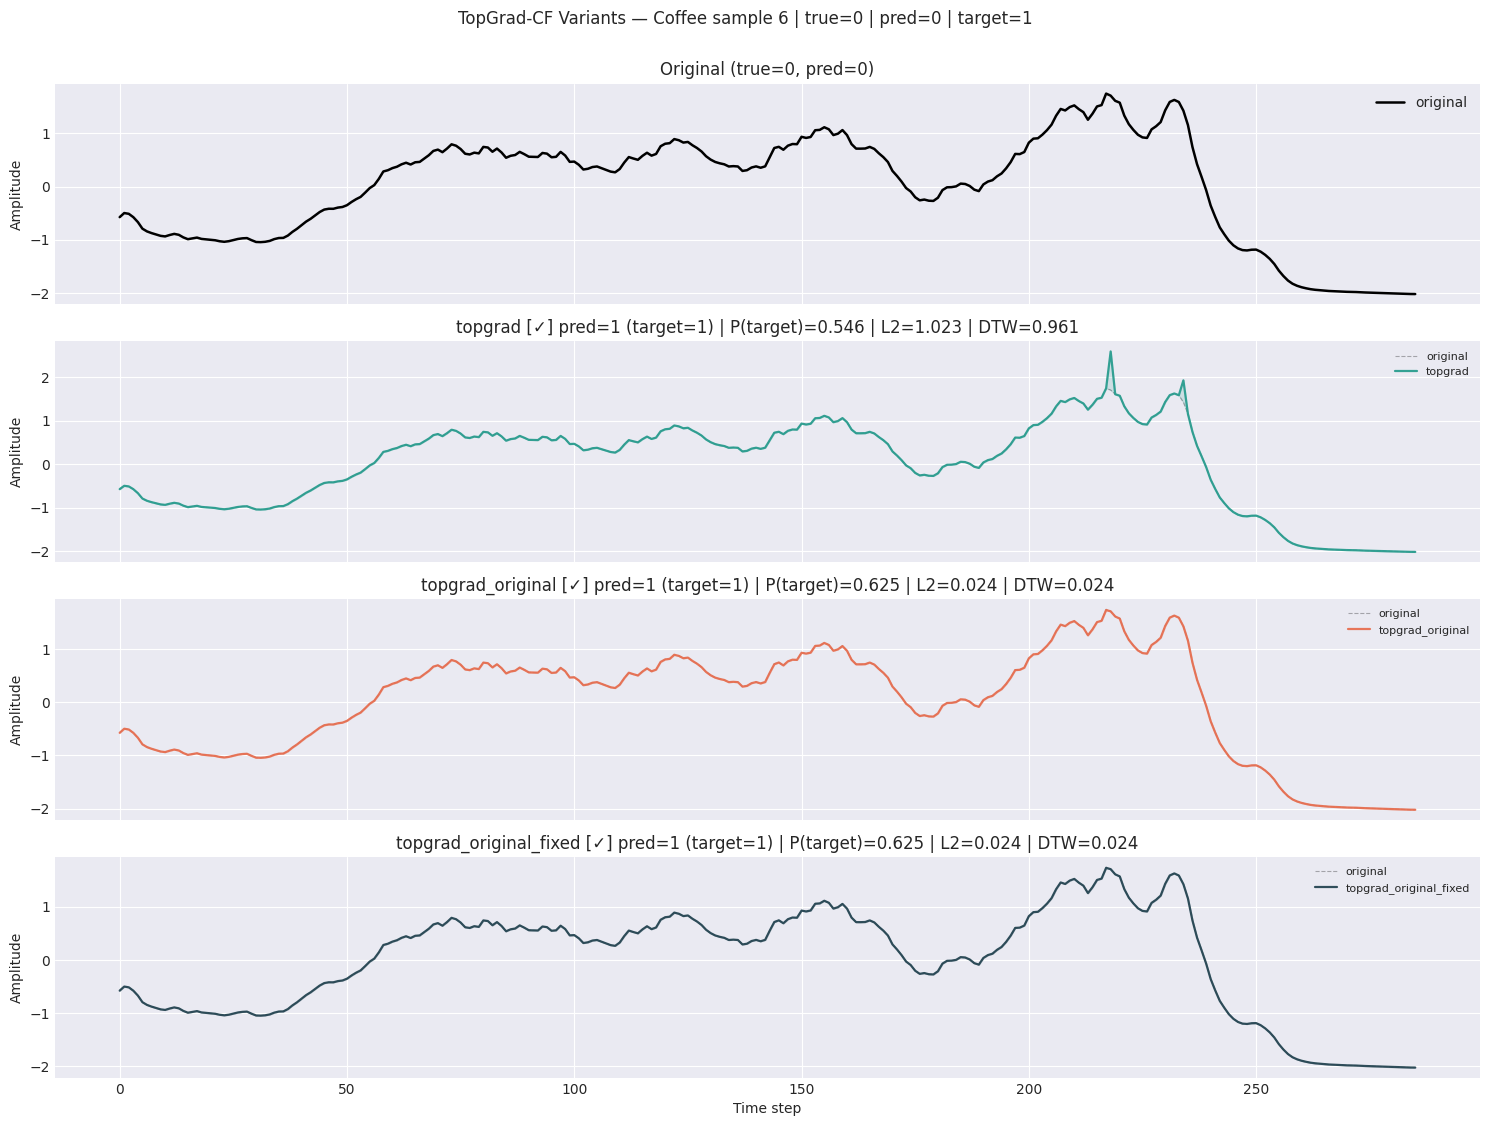

In [14]:
rep = all_cfs[rep_idx]
x_1d = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x_1d))

sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if pd.notna(row.get("pred_cf")) else None,
        "l2": float(row["l2_norm"]) if pd.notna(row.get("l2_norm")) else np.nan,
        "dtw": float(row["dtw_proximity"]) if pd.notna(row.get("dtw_proximity")) else np.nan,
        "sparsity": float(row["sparsity"]) if pd.notna(row.get("sparsity")) else np.nan,
        "target_proba_cf": float(row["target_proba_cf"]) if pd.notna(row.get("target_proba_cf")) else np.nan,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(METHODS)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(
    f"TopGrad-CF Variants — Coffee sample {rep_idx} | true={true_label} | pred={pred_orig} | target={target_class}",
    fontsize=12, y=1.001,
)

axes[0].plot(x_1d, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig})")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

for i, method_name in enumerate(METHODS, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    dtw_val = info.get("dtw", np.nan)
    tprob = info.get("target_proba_cf", np.nan)

    ax.plot(x_1d, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_1d = to_channel_first(cf)[0]
        ax.plot(cf_1d, linewidth=1.6, alpha=0.95, color=METHOD_COLORS[i - 1], label=method_name)
        ax.fill_between(x_axis, x_1d, cf_1d, color=METHOD_COLORS[i - 1], alpha=0.15)

    status = "✓" if worked else "✗"
    ax.set_title(
        f"{method_name} [{status}] pred={pred_cf} (target={target_class}) "
        f"| P(target)={tprob:.3f} | L2={l2_val:.3f} | DTW={dtw_val:.3f}"
    )
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

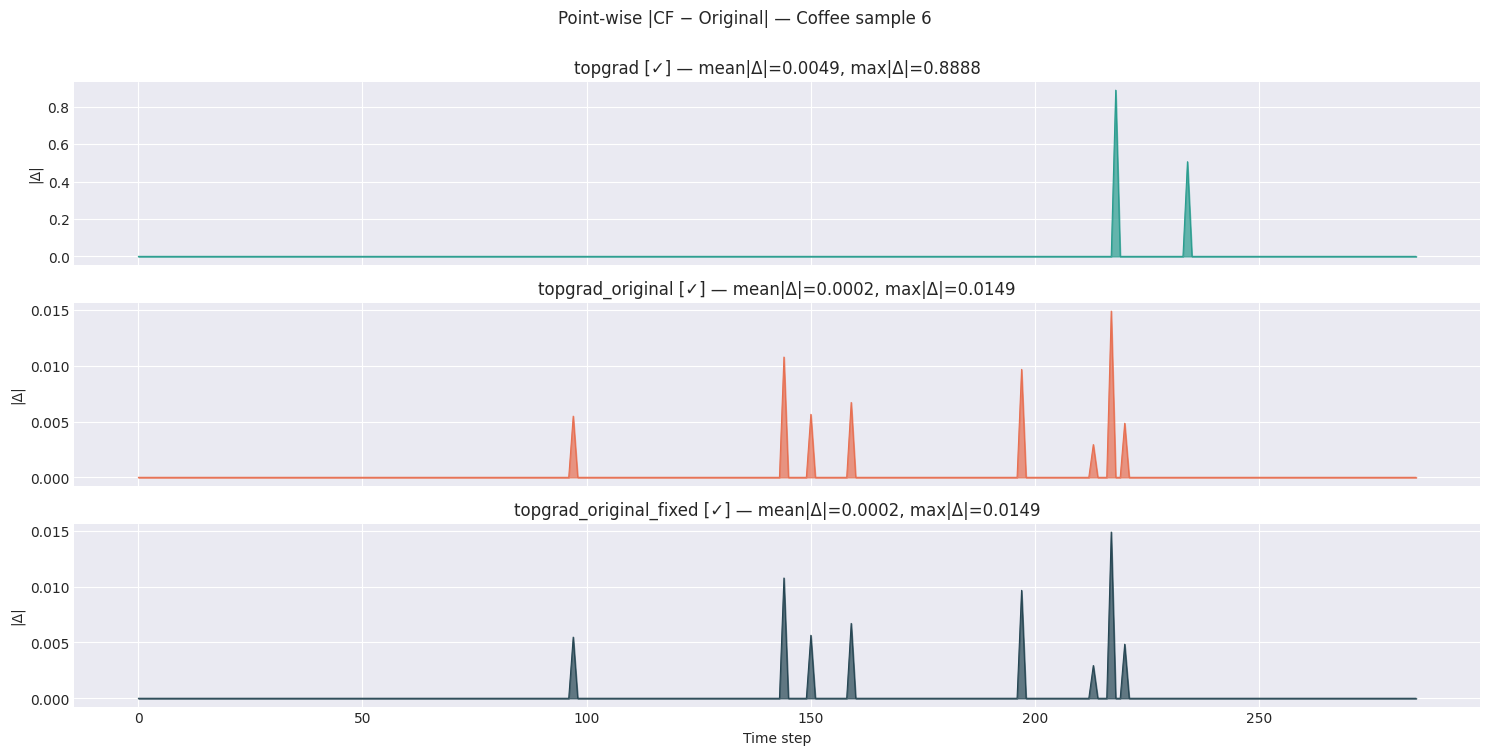

In [15]:
# Point-wise |CF − original| for each method
fig, axes = plt.subplots(len(METHODS), 1, figsize=(15, 2.5 * len(METHODS)), sharex=True)
fig.suptitle(f"Point-wise |CF − Original| — Coffee sample {rep_idx}", fontsize=12, y=1.001)
if len(METHODS) == 1:
    axes = [axes]

for i, method_name in enumerate(METHODS):
    ax = axes[i]
    cf = rep.get(method_name)
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method_name)
        continue
    diff = np.abs(to_channel_first(cf)[0] - x_1d)
    info = info_lookup.get(method_name, {})
    status = "✓" if info.get("success", False) else "✗"
    ax.fill_between(x_axis, 0, diff, color=METHOD_COLORS[i], alpha=0.7)
    ax.plot(diff, color=METHOD_COLORS[i], linewidth=0.8)
    ax.set_title(f"{method_name} [{status}] — mean|Δ|={diff.mean():.4f}, max|Δ|={diff.max():.4f}")
    ax.set_ylabel("|Δ|")

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

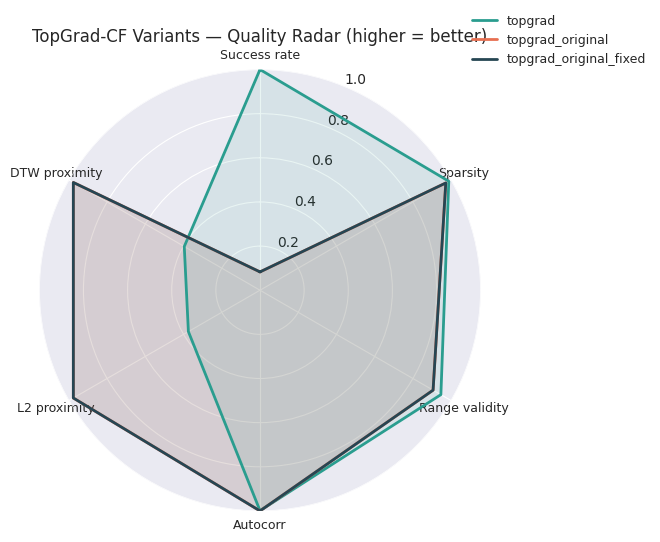

In [16]:
# Radar chart summarising key metrics (all normalised so higher = better)
radar_metrics = [
    "success_rate_norm", "sparsity_mean", "range_validity_mean",
    "autocorr_mean", "l2_score", "dtw_score",
]
radar_labels = [
    "Success rate", "Sparsity", "Range validity",
    "Autocorr", "L2 proximity", "DTW proximity",
]

plot_df2 = plot_df.copy()
plot_df2["success_rate_norm"] = plot_df2["success_rate"] / 100.0
plot_df2["l2_score"] = 1.0 / (1.0 + plot_df2["l2_norm_mean"].fillna(np.inf))
plot_df2["dtw_score"] = 1.0 / (1.0 + plot_df2["dtw_proximity_mean"].fillna(np.inf))

N_ax = len(radar_metrics)
angles = [n / float(N_ax) * 2 * np.pi for n in range(N_ax)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_ylim(0, 1)

for row_i, row in plot_df2.iterrows():
    vals = [float(row.get(m, 0) or 0) for m in radar_metrics]
    vals += vals[:1]
    color = METHOD_COLORS[row_i % len(METHOD_COLORS)]
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=row["method"], color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_title("TopGrad-CF Variants — Quality Radar (higher = better)", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## Ablation: does the missing classifier loss actually matter?

`topgrad_cf`'s "Deviations" note claims that always including the classifier loss
(`classification_weight`) — which the reference implementation computes but never adds
into its optimised objective for Keras/autograd models (`Methods/TopGrad-CF.py`, the
`self.loss_opt = self.loss_dist + sparsity + smoothness` line) — is what makes convergence
reliable. We can check that claim directly: run `topgrad_cf` on the representative sample
above with `classification_weight=1.0` (default) vs. `0.0` (replicating the reference's
omission), everything else identical.

classification_weight=1.0 (default) : pred=1, target=1, P(target)=0.5229, L1 dist=1.395
classification_weight=0.0 (reference): pred=0, target=1, P(target)=0.3002, L1 dist=0.022


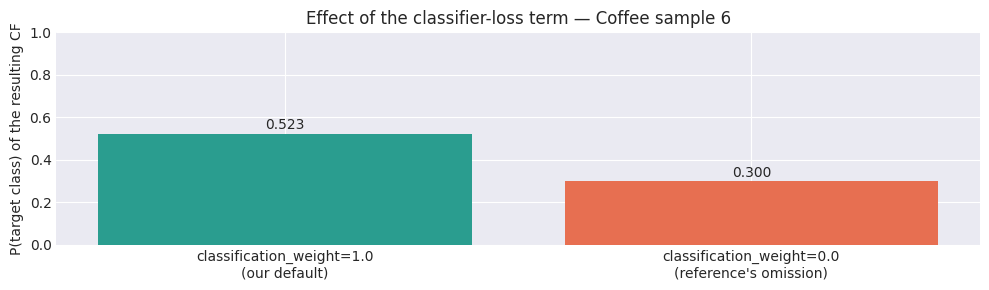

In [17]:
sample_rep = rep["sample"]
target_rep = rep["target_class"]

cf_with, scores_with = topgrad_cf(
    sample_rep, model, target_class=target_rep, dataset=background_dataset,
    classification_weight=1.0, **{k: v for k, v in TOPGRAD_KWARGS.items() if k != "verbose"},
)
cf_without, scores_without = topgrad_cf(
    sample_rep, model, target_class=target_rep, dataset=background_dataset,
    classification_weight=0.0, **{k: v for k, v in TOPGRAD_KWARGS.items() if k != "verbose"},
)

p_with = float(np.exp(scores_with[target_rep]) / np.exp(scores_with).sum())
p_without = float(np.exp(scores_without[target_rep]) / np.exp(scores_without).sum())

print(f"classification_weight=1.0 (default) : pred={int(np.argmax(scores_with))}, "
      f"target={target_rep}, P(target)={p_with:.4f}, L1 dist={np.abs(cf_with - sample_rep).sum():.3f}")
print(f"classification_weight=0.0 (reference): pred={int(np.argmax(scores_without))}, "
      f"target={target_rep}, P(target)={p_without:.4f}, L1 dist={np.abs(cf_without - sample_rep).sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(["classification_weight=1.0\n(our default)", "classification_weight=0.0\n(reference's omission)"],
       [p_with, p_without], color=["#2a9d8f", "#e76f51"])
ax.set_ylabel("P(target class) of the resulting CF")
ax.set_ylim(0, 1)
ax.set_title(f"Effect of the classifier-loss term — Coffee sample {rep_idx}")
for i, v in enumerate([p_with, p_without]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## Key findings

**1. `Main.py`'s own call site has a `target_classid` bug that silently disables the outer search loop.**
`TFCounterFactual.__init__` takes a `target_classid` parameter (default `0`) that
`_minimize_loss`'s outer while-loop uses to check whether the counterfactual is "done"
(`pred_p[0][self.target_classid] < tr_accuracy`, `tr_accuracy=0.95`). `Main.py`'s own
`process_dataset_timex` never passes `target_classid` when constructing `TFCounterFactual`
— only `target_class` — so it silently stays `0` regardless of the actual target. On Coffee
(binary, classes `{0, 1}`), whenever the *original* sample is class 0 (i.e. we're searching
for a class-1 counterfactual), the stopping check ends up reading `P(class 0)` — which
starts high and barely moves — so the while-loop exits after essentially one segment-growth
step instead of the ~65 the schedule allows for. `topgrad_original_fixed` above passes
`target_classid=target_class` to correct exactly this one argument; compare its row in the
summary table to `topgrad_original`'s to see the effect (`n_successful`, `runtime_s_mean`,
and `target_proba_cf_mean` in particular — the fixed variant runs the full rate schedule and
takes noticeably longer per sample as a result).

**2. Even with that fixed, the reference's Keras/autograd path never optimises toward the
target class directly.** As documented in `topgrad_cf.py` and confirmed by the ablation
above: `Methods/TopGrad-CF.py` computes a classifier loss (`self.loss_pred`) but its
`self.loss_opt` for Keras models is `self.loss_dist + sparsity + smoothness` — proximity to
the original sample, proximity to the DBA prototype, and smoothness, with no classifier
term. Whatever class-flipping happens is a side effect of pulling the candidate toward a
prototype that happens to belong to the target class, filtered through top-k gradient
masking of that *distance* gradient — not a gradient of the model's own prediction. The bar
chart's "Mean target-class probability of CF" panel and the ablation above show what adding
that term back (`topgrad_cf`'s default) does on identical inputs.

**3. Building this notebook surfaced a bug in `topgrad_cf.py` itself, now fixed.** The first
version of our port summed the L1/L2 proximity and smoothness terms over all `L` time steps
(matching the reference's own `tf.reduce_sum`), while the classifier loss it adds on top
stays `O(1)` regardless of `L`. That's invisible on the short synthetic series used for the
port's original smoke tests, but on Coffee's length-286 series the summed terms swamped the
classifier loss almost completely — an early run of this exact notebook measured `topgrad` at
**0/12 successes**, doing *worse* than the reference despite the fix in finding 2. Switching
those terms to their *mean* (dividing by the number of elements, keeping `lam` /
`sparsity_weight` / `smoothness_weight` as the tunable knobs) restored the classifier loss's
relative influence regardless of series length; the `topgrad` row above and the ablation
were produced with that fix in place. See the "mean, not sum" bullet in `topgrad_cf.py`'s
module-docstring "Deviations" list.

**4. Context.** This is not a Table-2-style reproduction: the paper is very recent (ICPR
2026, not yet indexed with public reviews) and paywalled, so we compare against the authors'
own runnable code rather than reported numbers. `topgrad_original*` uses the *reference's*
Keras classifier and DBA prototypes (not `topgrad_cf`'s NUN prototype or our `SimpleCNN`),
so `validity`/`target_proba_cf` for those rows are judged against a different model than
`topgrad`'s row — proximity/sparsity/DTW metrics are model-independent and comparable
directly. All three findings above were confirmed by actually running the cloned reference
code, and iterating on our own, end-to-end in this notebook — not solely by reading source.

In [18]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.
